OBJECTIVE OF THIS MODULE

We will use:

→ Isolation Forest

to detect:

abnormal electricity consumption
suspicious load behavior
inefficient enterprise regions
operational outliers

Why Isolation Forest?

Because it:

works without labeled anomaly data
is industry-standard
handles multidimensional business KPIs well


STEP 1 — Import Libraries


In [1]:
# ======================================
# IMPORT LIBRARIES
# ======================================

import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — Load Dataset

In [2]:
# ======================================
# LOAD DATASET
# ======================================

df = pd.read_csv("../data/final_energy_dataset.csv")

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency,efficiency_category
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938,HIGH EFFICIENCY
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578,MEDIUM EFFICIENCY
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432,HIGH EFFICIENCY
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751,HIGH EFFICIENCY
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000,MEDIUM EFFICIENCY


STEP 3 — Select Anomaly Features

In [3]:
# ======================================
# SELECT FEATURES
# ======================================

anomaly_features = [
    'totservices',
    'billdservices',
    'units',
    'load',
    'units_per_service',
    'service_utilization_ratio',
    'avg_load_per_service',
    'load_efficiency'
]

anomaly_df = df[anomaly_features].copy()

display(anomaly_df.head())

,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency
0,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938
1,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578
2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432
3,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751
4,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000


STEP 4 — Handle Missing Values

In [4]:
# ======================================
# HANDLE MISSING VALUES
# ======================================

anomaly_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

anomaly_df.fillna(0, inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


STEP 5 — Train Isolation Forest

In [5]:
# ======================================
# TRAIN ISOLATION FOREST
# ======================================

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

iso_forest.fit(anomaly_df)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


STEP 6 — Predict Anomalies

In [6]:
# ======================================
# PREDICT ANOMALIES
# ======================================

df['anomaly_score'] = iso_forest.decision_function(
    anomaly_df
)

df['anomaly'] = iso_forest.predict(
    anomaly_df
)

print("Anomaly prediction completed.")

Anomaly prediction completed.


IMPORTANT OUTPUT UNDERSTANDING

Isolation Forest labels:

| Value | Meaning |
| ----- | ------- |
| 1     | Normal  |
| -1    | Anomaly |


STEP 7 — Count Anomalies

In [7]:
# ======================================
# ANOMALY COUNT
# ======================================

anomaly_counts = df['anomaly'].value_counts()

print(anomaly_counts)

anomaly
 1    15426
-1      478
Name: count, dtype: int64


STEP 8 — Extract High-Risk Areas

In [8]:
# ======================================
# HIGH-RISK ANOMALY AREAS
# ======================================

anomalies = df[df['anomaly'] == -1]

display(
    anomalies[
        [
            'circle',
            'division',
            'area',
            'units',
            'load',
            'anomaly_score'
        ]
    ].head(20)
)

,circle,division,area,units,load,anomaly_score
32,BANJARA HILLS,GREEN LANDS,CT METERS,473944,5738.89,-0.125218
71,BANJARA HILLS,GREEN LANDS,GRC HV BORABANDA,266731,1858.16,-0.034230
107,BANJARA HILLS,GREEN LANDS,CT METERS HV(GRC) ERRAGADDA,188230,2108.72,-0.042308
143,BANJARA HILLS,GREEN LANDS,GRC HV MOTINAGAR,256938,2208.06,-0.010905
162,BANJARA HILLS,BANJARA HILLS,HV ROAD NO 56 TO 68 & 10 TO 22,822071,9433.00,-0.146793
183,BANJARA HILLS,BANJARA HILLS,"ARUNDHOYA,IMAGE GARDEN, HARIZA",1789622,22770.83,-0.199640
186,BANJARA HILLS,BANJARA HILLS,CT METERS & NET METERS,229027,2233.00,-0.045545
189,BANJARA HILLS,BANJARA HILLS,GRC HIGH VALUES,282398,3385.57,-0.035863
195,BANJARA HILLS,BANJARA HILLS,COD TO MADHAPUR PS SIDE GRC,1153297,12523.84,-0.176886
196,BANJARA HILLS,BANJARA HILLS,"CYBER TOWER AREA,PATRIKANAGAR",1778541,23291.56,-0.198551


STEP 9 — Visualize Anomalies

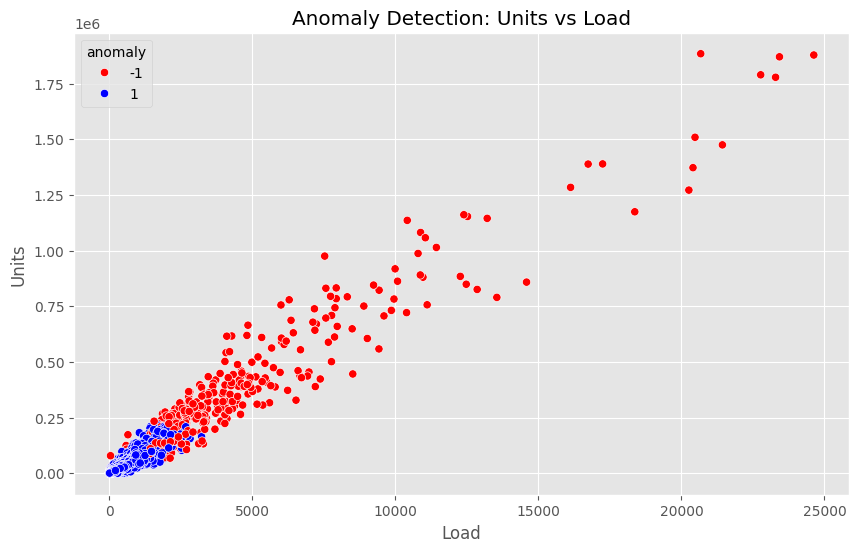

In [9]:
# ======================================
# ANOMALY VISUALIZATION
# ======================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='load',
    y='units',
    hue='anomaly',
    palette={
        1: 'blue',
        -1: 'red'
    }
)

plt.title("Anomaly Detection: Units vs Load")

plt.xlabel("Load")

plt.ylabel("Units")

plt.show()

STEP 10 — Top Anomaly Regions

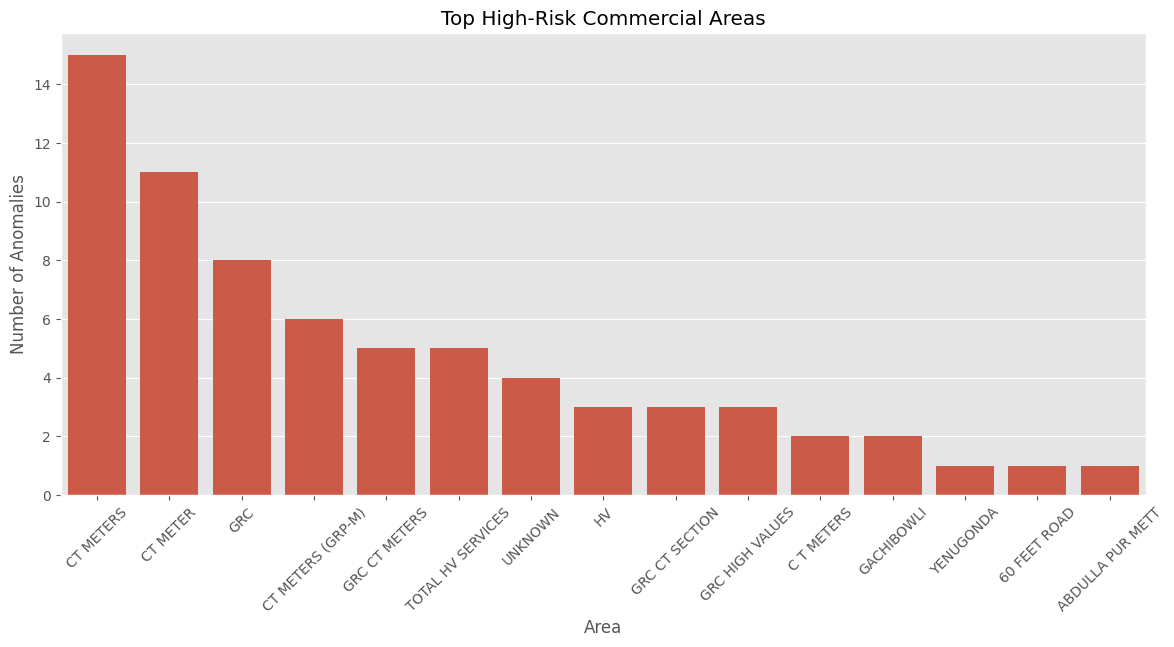

In [10]:
# ======================================
# TOP ANOMALY REGIONS
# ======================================

top_anomaly_areas = (
    anomalies.groupby('area')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_anomaly_areas.index,
    y=top_anomaly_areas.values
)

plt.title("Top High-Risk Commercial Areas")

plt.xlabel("Area")

plt.ylabel("Number of Anomalies")

plt.xticks(rotation=45)

plt.show()

STEP 11 — Risk Categorization

In [11]:
# ======================================
# RISK CATEGORIZATION
# ======================================

conditions = [
    df['anomaly_score'] < -0.15,
    (df['anomaly_score'] >= -0.15) &
    (df['anomaly_score'] < 0),
    df['anomaly_score'] >= 0
]

labels = [
    'HIGH RISK',
    'MEDIUM RISK',
    'LOW RISK'
]

df['risk_category'] = np.select(
    conditions,
    labels,
    default='UNKNOWN'
)

display(
    df[
        [
            'area',
            'anomaly_score',
            'risk_category'
        ]
    ].head()
)

,area,anomaly_score,risk_category
0,MAHATMA NAGAR,0.248554,LOW RISK
1,N.R.R.PURAM -I (S),0.249390,LOW RISK
2,N.R.R.PURAM SITE - II,0.245748,LOW RISK
3,N.R.R.PURAM SITE - III,0.216413,LOW RISK
4,N.R.R.PURAM SITE -I,0.236657,LOW RISK


STEP 12 — Risk Distribution Chart

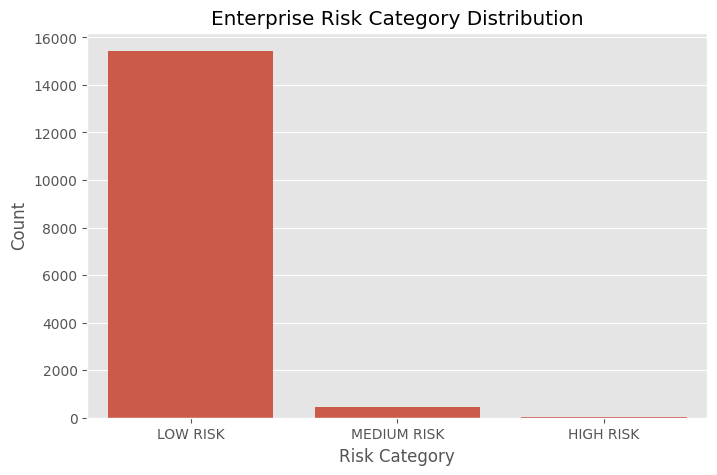

In [12]:
# ======================================
# RISK DISTRIBUTION
# ======================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='risk_category'
)

plt.title("Enterprise Risk Category Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.show()

STEP 13 — Export Final Intelligence Dataset

In [13]:
# ======================================
# EXPORT FINAL DATASET
# ======================================

df.to_csv(
    "../data/final_enterprise_energy_intelligence.csv",
    index=False
)

print("Final enterprise intelligence dataset exported successfully.")

Final enterprise intelligence dataset exported successfully.
